# <center> Практические задания по цифровой обработке сигналов </center>
# <center> Четвертая лабораторная работа </center>
# <center> Акустические признаки </center>

In [ ]:
import os
from glob import glob
from pathlib import Path

import IPython.display as ipd
import librosa
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

%matplotlib inline

import warnings

warnings.filterwarnings("ignore")

Функция отрисовки аудио сигнала

In [ ]:
def draw_waveform(wav: np.ndarray, sr: int, figsize: tuple[int, int] = (14, 5)) -> None:
    # Отрисовка звукового сигнала во временной области
    plt.figure(figsize=figsize)
    librosa.display.waveshow(wav, sr=sr)
    plt.show()

### Для выполнения задания нам понадобится датасет *yes/no*. 
Про датасет можно почитать тут https://www.openslr.org/1/

In [ ]:
# Скачаем его
#  надёжнее использовать скачивание вручную, либо попробовать строчку ниже
# ![ ! -f  waves_yesno.tar.gz ] && wget https://www.openslr.org/resources/1/waves_yesno.tar.gz
# И распакуем
# !tar -xvzf waves_yesno.tar.gz

P.S если у вас Windows, или по каким-либо еще причинам данные не скачались, 
то их можно скачать руками отсюда: https://www.openslr.org/1/

### Загрузим один из файлов

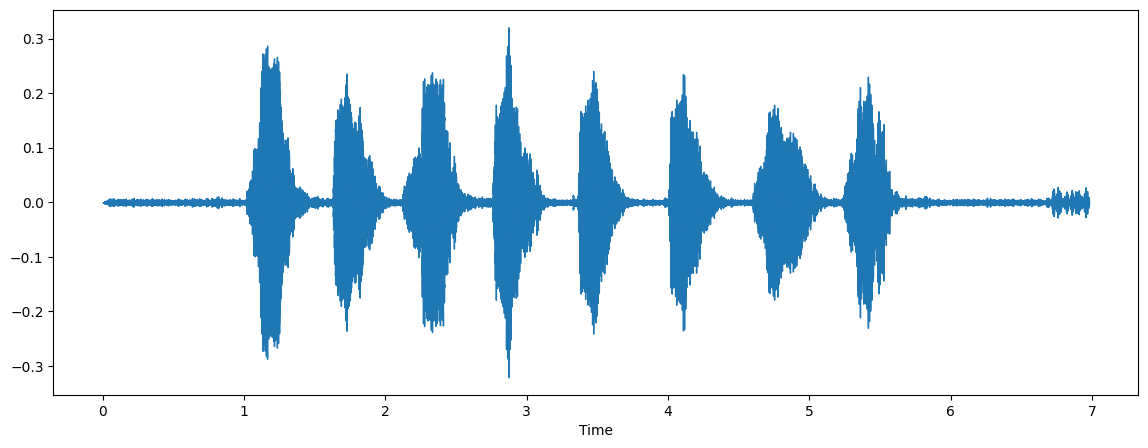

In [ ]:
wav, sr = librosa.load("waves_yesno/0_1_0_1_1_1_0_0.wav", sr=None)
draw_waveform(wav, sr)
ipd.Audio(wav, rate=sr)

Как можно услышать, в этом датасете произносятся какие-то два слова (yes/no на иврите). Каждый файл состоит из 8 произнесений. Метки слов указаны в названиях файлов.

Построим спектрограмму загруженной вавки

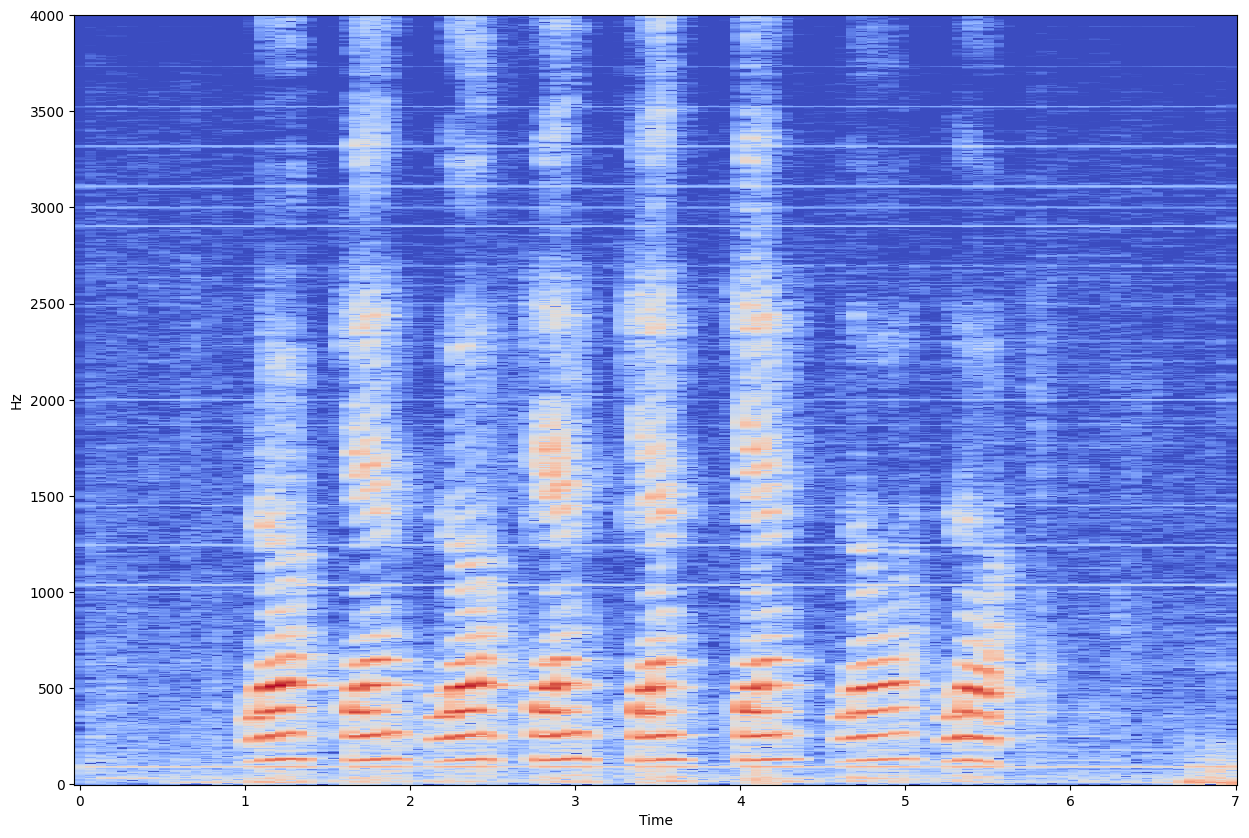

In [ ]:
stft = librosa.stft(wav)
stft_db = librosa.amplitude_to_db(abs(stft))
plt.figure(figsize=(15, 10))
librosa.display.specshow(stft_db, sr=sr, x_axis="time", y_axis="hz")
plt.show()

# Задание 0.1: Анализ спектрограммы (0.5 балла)
1. Посмотрите на спектрограмму и попробуйте найти признаки, по которым можно отличить произнесение "yes" от "no". 
1. В каких частотах находится основная энергия этого речевого сигнала? 

### 1. Посмотрите на спектрограмму и попробуйте найти признаки, по которым можно отличить произнесение "yes" от "no". 

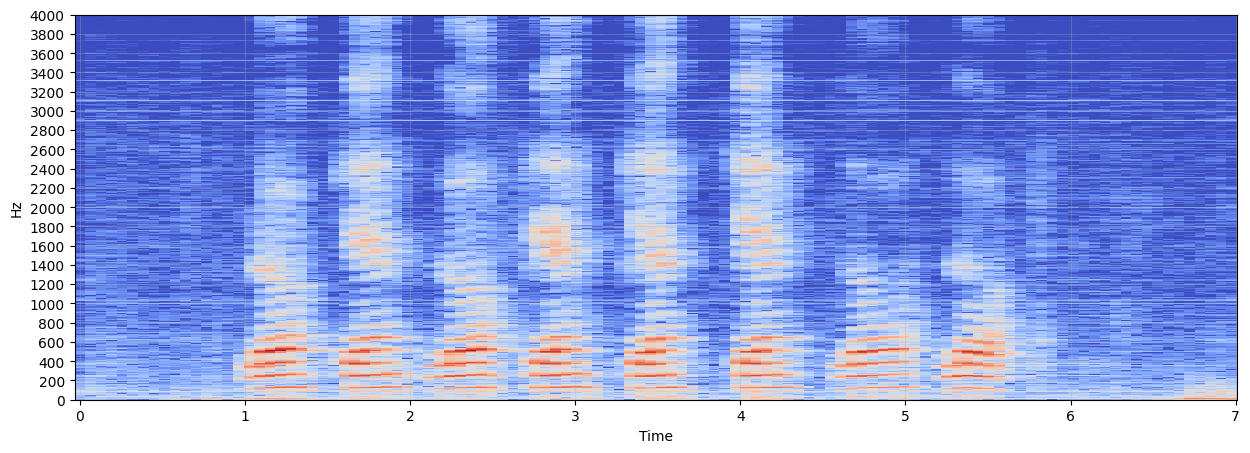

In [ ]:
# YOUR ANSWER HERE
stft = librosa.stft(wav)
stft_db = librosa.amplitude_to_db(abs(stft))
plt.figure(figsize=(15, 5))

librosa.display.specshow(stft_db, sr=sr, x_axis="time", y_axis="hz")

plt.ylim(0, 4000)

plt.yticks(np.arange(0, 4100, 200))
plt.grid(True, alpha=0.3)

plt.show()

На спектрограме видно, что когда говорят да, на частотах 2700-3000 есть соединение с верхней частью. Также у да больше энергии в центральной части между 1200 Гц и 2600 Гц. Соответственно, говорят нет, да, нет, да, да, да, нет, нет

### 2. В каких частотах находится основная энергия этого речевого сигнала?

В обоих случаях в районе 100-800 Гц. У да дополнительно ещё в районе 1200-2600 Гц

# Задание 1: Мел-шкала (1 балл)
Нарисовать спектрограму в [mel-шкале](https://en.wikipedia.org/wiki/Mel_scale). 
Использовать формулу, представленную Дугласом О'Шонесси.

In [ ]:
def mel(spec: np.ndarray | int) -> np.ndarray:
    # spec - stft spectrogram

    # YOUR CODE HERE

    return 2595.0 * np.log10(1.0 + spec / 700.0)

In [ ]:
def test_mel() -> None:
    x = np.random.randint(100, size=(1000, 100))
    x_mel = mel(x)
    x_hz = 700.0 * (10.0 ** (x_mel / 2595.0) - 1.0)
    assert np.allclose(x, x_hz), "TEST Hertz -> Mel -> Hertz  failed. "
    print("All ok!")


test_mel()

All ok!


# Мел-фильтры
Одними из наиболее популярных акустических признаков являются Filter Banks (fbanks). 
fbanks вычисляются применением нескольких (количество фильтров = количество fbanks) треугольных фильтров к мел-спектрограмме. Чтобы не делать два действия со спектрограммой, переход к мел-шкале и применение фильтров в мел-шкале можно заменить на перевод мел-фильтров в Герц-шкалу и применение их к Герц-спектрограмме.



# Задание 2 (3 балла)
<!-- Реализуйте функцию вычисления fbank по формулам библиотеки librosa.  -->

### Мел-фильтры

Реализуйте функцию вычисления fbank.
Помимо лекций описание формул можно посмотреть тут: https://studbooks.net/2037683/informatika/raschyot_filtrov. 

In [ ]:
def mel_filters_pure(sr: int, n_fft: int, n_mels: int) -> np.ndarray:
    # функция построения треугольных мел-фильтров в герц-шкале
    # sr - sample rate
    # n_fft - length of the FFT window
    # n_mels - number of filters
    # return mel filters matrix. [n_mel, n_fft]

    # YOUR CODE HERE
    f_min = 0
    # восстанавливаем максимальную оригинальную частоту по теореме Котельникова
    f_max = sr // 2

    # берём мел частоты
    mel_min = mel(f_min)
    mel_max = mel(f_max)

    mel_points = np.linspace(mel_min, mel_max, n_mels + 2)
    hz_points = 700.0 * (10.0 ** (mel_points / 2595.0) - 1.0)

    bin_indices = np.floor((n_fft + 1) * hz_points / sr).astype(int)

    filters = np.zeros((n_mels, n_fft // 2 + 1))

    for i in range(1, n_mels + 1):
        f_left = bin_indices[i - 1]
        f_center = bin_indices[i]
        f_right = bin_indices[i + 1]

        for k in range(f_left, f_center):
            filters[i - 1, k] = (k - f_left) / (f_center - f_left)
        for k in range(f_center, f_right):
            filters[i - 1, k] = (f_right - k) / (f_right - f_center)

    return filters

Обратите внимание что реализации базовых функций таких как вычисления fbank могут отличаться в различных широко используемых библиотеках. Как правило это не критично для большинства практических задач, но бывают сложности при поиске ошибок и сравнении реализаций. 
Реализуйте функцию вычисления fbank по формулам библиотеки librosa по аналогии с открытым исходным кодом. Формулы, используемые в библиотеке librosa, отличаются от используемых в лекциях и некоторых других источниках. Обратите внимание на использование np.diff и np.substract, а также на нормализацию slaney. https://librosa.org/doc/latest/_modules/librosa/filters.html#mel

In [ ]:
def mel_filters_librosa(sr: int, n_fft: int, n_mels: int) -> np.ndarray:
    # функция построения треугольных мел-фильтров в герц-шкале
    # sr - sample rate
    # n_fft - length of the FFT window
    # n_mels - number of filters
    # return mel filters matrix. [n_mel, n_fft]

    # YOUR CODE HERE
    f_min = 0.0
    f_max = sr / 2.0
    n_mels = int(n_mels)

    mel_min = mel(f_min)
    mel_max = mel(f_max)

    mel_points = np.linspace(mel_min, mel_max, n_mels + 2)
    hz_points = 700.0 * (10.0 ** (mel_points / 2595.0) - 1.0)

    fftfreqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

    fdiff = np.diff(hz_points)
    ramps = np.subtract.outer(hz_points, fftfreqs)

    filters = np.zeros((n_mels, n_fft // 2 + 1))

    for i in range(n_mels):
        lower = -ramps[i] / fdiff[i]
        upper = ramps[i + 2] / fdiff[i + 1]

        filters[i] = np.maximum(0, np.minimum(lower, upper))

    enorm = 2.0 / (hz_points[2 : n_mels + 2] - hz_points[:n_mels])
    filters *= enorm[:, np.newaxis]

    return filters

In [ ]:
assert mel_filters_librosa(32, 46, 4).shape == (4, 24) and mel_filters_librosa(65, 45, 5).shape == (5, 23), (
    "Wrong shape"
)
assert np.allclose(mel_filters_librosa(16, 8, 4), librosa.filters.mel(sr=16, n_fft=8, n_mels=4, htk=True))
assert np.allclose(mel_filters_librosa(8600, 512, 40), librosa.filters.mel(sr=8600, n_fft=512, n_mels=40, htk=True))
print("All ok!")

All ok!


Можно заметить, что есть небольшое расхождение в результатах формул. Для большенства практических задач это не существенно, но эти различия полезно знать при собственных экспериментах с аудио фичами а так же в случаях отладки и поиске ошибок.

Далее будем использовать функцию *mel_filters_librosa*

In [ ]:
def get_fbanks(wav: np.ndarray, sr: int, window_ms: int = 25, step_ms: int = 10, n_fbanks: int = 40) -> np.ndarray:
    # wav - input signal
    # sr - sample rate
    # window_ms - window length in milliseconds
    # step_ms - stft step in milliseconds
    # n_fbanks - number of filters
    # return fbank matrix [n_fbanks, time]

    # YOUR CODE HERE

    n_fft = int(sr * window_ms / 1000)
    hop_length = int(sr * step_ms / 1000)

    stft = librosa.stft(y=wav, n_fft=n_fft, hop_length=hop_length, window="hann")
    power_spectrum = np.abs(stft) ** 2
    mel_filters = mel_filters_librosa(sr, n_fft, n_fbanks)

    return mel_filters @ power_spectrum

In [ ]:
def test_fbank(wav: np.ndarray, sr: int, window_ms: int = 25, step_ms: int = 10, n_fbanks: int = 40) -> float | int:
    n_fft = window_ms * sr // 1000
    hop_length = step_ms * sr // 1000
    fbanks_lib = librosa.feature.melspectrogram(
        y=wav, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_fbanks, htk=True
    )
    fbanks = get_fbanks(wav, sr, window_ms=window_ms, step_ms=step_ms, n_fbanks=n_fbanks)

    if fbanks_lib.shape != fbanks.shape:
        print("TEST FAILED")
        print(f"Shape {fbanks_lib.shape} != {fbanks.shape}")
        return 1

    if not np.allclose(fbanks_lib, fbanks):
        print("TEST PASSED BUT WITH CALCULATION ERROR")
        print(f"Average diff is {np.mean(np.abs(fbanks_lib - fbanks))}")
        return np.mean(np.abs(fbanks_lib - fbanks))

    print("TEST PASSED")
    return 0


assert test_fbank(wav[: sr * 1], sr) <= 0.0003, "1 sec wav test failed"
assert test_fbank(wav, sr) <= 0.0003, "All wav test failed"
print("All ok!")

TEST PASSED
TEST PASSED
All ok!


In [ ]:
window_ms = 25
step_ms = 10
n_fbanks = 40
n_fft = window_ms * sr // 1000
hop_length = step_ms * sr // 1000

Визуализируем полученные фильтрбанки самописными функциями и функциями либросы:

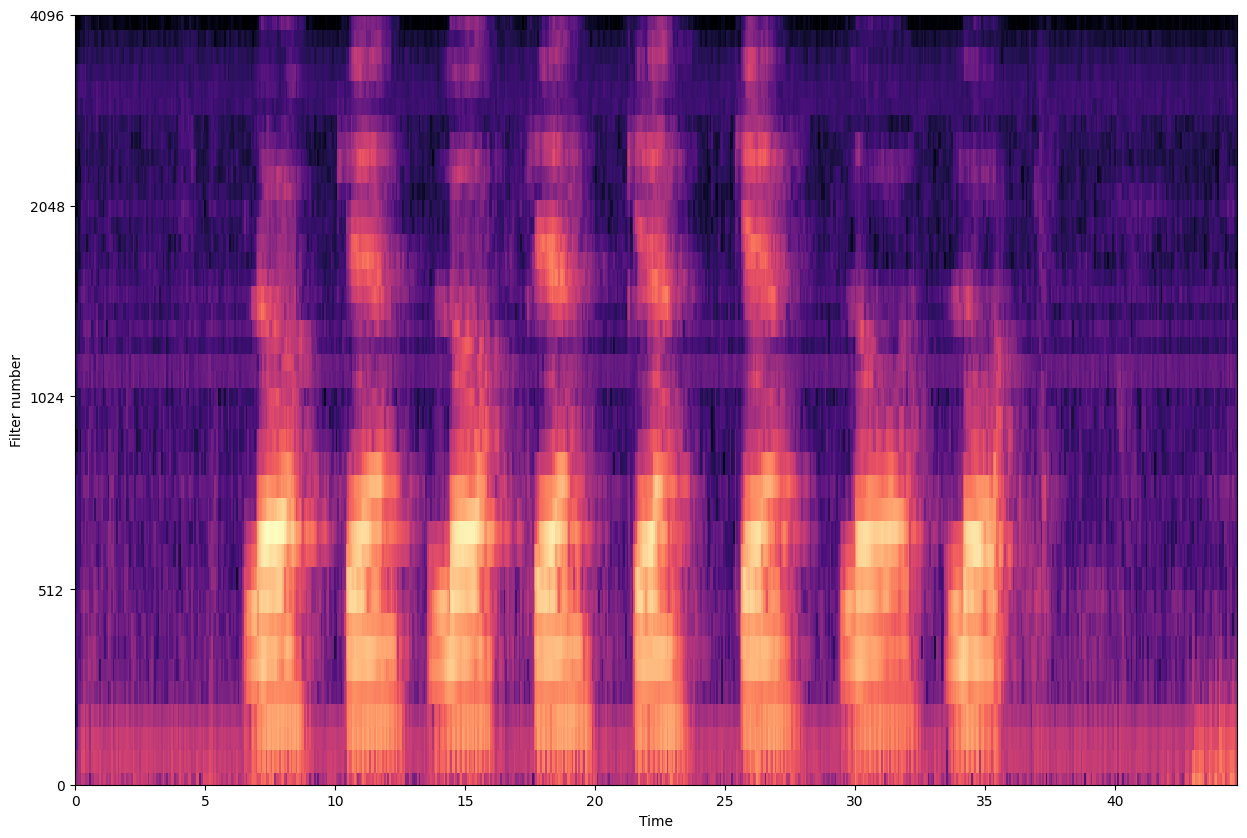

In [ ]:
fbanks = get_fbanks(wav, sr)
plt.figure(figsize=(15, 10))
librosa.display.specshow(librosa.power_to_db(fbanks), sr=sr, y_axis="mel", x_axis="time")
plt.ylabel("Filter number")
plt.ylim(0, 4096)
plt.show()

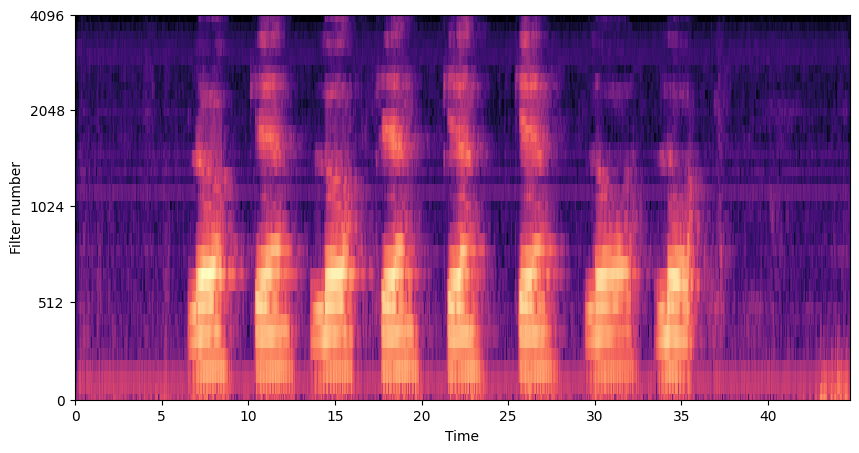

In [ ]:
fbanks_lib = librosa.feature.melspectrogram(y=wav, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_fbanks, htk=True)
plt.figure(figsize=(10, 5))
librosa.display.specshow(librosa.power_to_db(fbanks_lib), sr=sr, y_axis="mel", x_axis="time")
plt.ylabel("Filter number")
plt.ylim(0, 4096)
plt.show()

# Задание 4 (3 балла)
Реализовать вычисление [mfcc](https://en.wikipedia.org/wiki/Mel-frequency_cepstrum)



In [ ]:
def get_mfcc(
    wav: np.ndarray, sr: int, window_ms: int = 25, step_ms: int = 10, n_mfcc: int = 13, n_mels: int = 128
) -> np.ndarray:
    # wav - input signal
    # sr - sample rate
    # window_ms - window length in milliseconds
    # step_ms - stft step in milliseconds
    # n_mfcc - number of filters
    # return mfcc matrix [n_mfcc, time]

    # YOUR CODE HERE
    fbanks = get_fbanks(wav=wav, sr=sr, window_ms=window_ms, step_ms=step_ms, n_fbanks=n_mels)
    S_db = librosa.power_to_db(fbanks, ref=1.0, top_db=80.0)

    M = S_db.shape[0]
    mfcc = np.zeros((M, S_db.shape[1]))

    for l in range(M):
        cos_vector = np.cos(np.pi * l * (np.arange(M) + 0.5) / M)
        mfcc[l] = np.sum(S_db * cos_vector.reshape(-1, 1), axis=0)

    scale = np.sqrt(2.0 / M)
    mfcc *= scale
    mfcc[0] *= np.sqrt(0.5)

    return mfcc[:n_mfcc, :]

Возможно, появится ошибка вычислений. Надо просто смириться с тем, что она есть, и сделать так, чтобы она была ниже допустимой:

In [ ]:
def test_mfcc(wav: np.ndarray, sr: int, window_ms: int = 25, step_ms: int = 10, n_mfcc: int = 13) -> float | int:
    n_fft = window_ms * sr // 1000
    hop_length = step_ms * sr // 1000
    mfcc_lib = librosa.feature.mfcc(y=wav, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mfcc=n_mfcc, htk=True)
    mfcc = get_mfcc(wav, sr, window_ms=window_ms, step_ms=step_ms, n_mfcc=n_mfcc)

    if mfcc_lib.shape != mfcc.shape:
        print("TEST PASSED BUT WITH CALCULATION ERROR!")
        print(f"Shape {mfcc_lib.shape} != {mfcc.shape}")
        return 1

    if not np.allclose(mfcc_lib, mfcc):
        print("TEST PASSED BUT WITH CALCULATION ERROR")
        print(f"Average diff is {np.mean(np.abs(mfcc_lib - mfcc))}")
        return np.mean(np.abs(mfcc_lib - mfcc))

    print("TEST PASSED")
    return 0


assert test_mfcc(wav[: sr * 1], sr) <= 0.0005, "1 sec wav test failed"
assert test_mfcc(wav, sr) <= 0.0005, "All wav test failed"
print("All ok!")

TEST PASSED BUT WITH CALCULATION ERROR
Average diff is 6.800790663419861e-06
TEST PASSED BUT WITH CALCULATION ERROR
Average diff is 5.247174408901058e-06
All ok!


Визуализируем *mfcc*

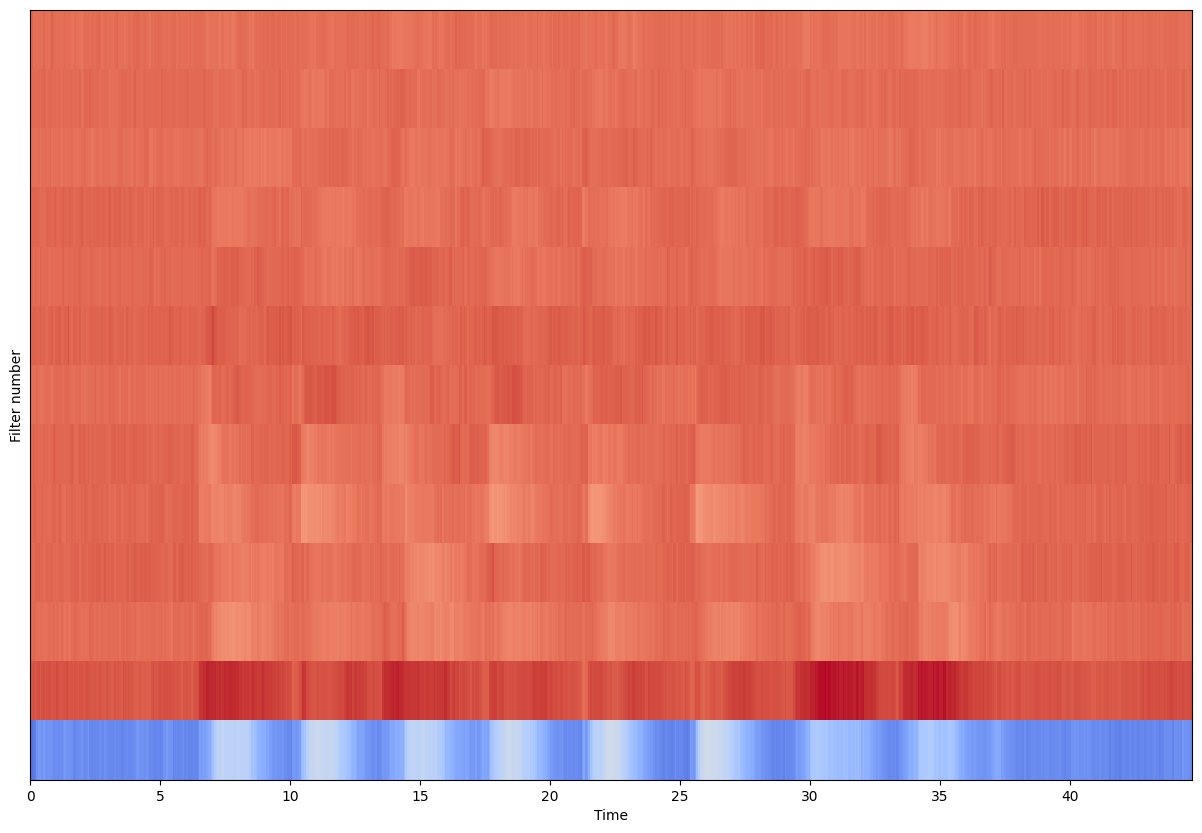

In [ ]:
mfcc = get_mfcc(wav, sr)
plt.figure(figsize=(15, 10))
librosa.display.specshow(mfcc, sr=sr, x_axis="time")
plt.ylabel("Filter number")
plt.show()

# Классификация слов
Построим простую систему, классифицирующую слова yes/no.

Загрузим весь датасет

In [ ]:
def load_yn_dataset(directory: str) -> tuple[list[int], list[int]]:
    X, labels = [], []
    bad_files = {"0_1_0_1_0_0_0_0"}
    for f in glob(directory + "/*.wav"):
        name = os.path.basename(f)[:-4]
        if name in bad_files:
            continue
        y = [int(l) for l in name.split("_")]
        x, _ = librosa.load(f, sr=None)
        X.append(x)
        labels.append(y)

    return X, labels


X, Y = load_yn_dataset("waves_yesno/")

Послушаем одну вавку:

In [ ]:
wav, sr = librosa.load("waves_yesno/0_1_0_1_0_0_0_0.wav", sr=None)
ipd.Audio(wav, rate=sr)

Отделим 20% для теста

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

Я перепишу дальше, чтобы сразу мел фичи извлекать

# Задание *5 (1 балл)
Voice Activity Detector (VAD) определяет, есть ли речь в текущем кадре.
Реализуйте простой VAD. Настройте VAD, чтобы хорошо определялись границы слов.

Подсказка:
Можно отличать паузу от речи по энергии mfcc спектра( или части спектра). Чтобы предотвратить скачки на краях слов, воспользуйтесь сверткой со сглаживающим окном, например, Ханна.

In [ ]:
def mfcc_vad(wav: np.ndarray, sr: int = sr, n_expected: int = 8, threshold: float = 0.57, counter: int = 0) -> list:
    win_length = int(0.025 * sr)
    hop_length = int(0.010 * sr)

    # считаем энергию c MFCC, почти то же самое, что было во второй лабе
    mfcc = librosa.feature.mfcc(y=wav, sr=sr, n_mfcc=13, n_fft=win_length, hop_length=hop_length, win_length=win_length)
    energy = mfcc[0]

    energy_norm = (energy - np.mean(energy)) / (np.std(energy) + 1e-6)
    detected = energy_norm > threshold

    frame_times = librosa.frames_to_time(np.arange(len(detected)), sr=sr, hop_length=hop_length)

    segments = []
    start_time = None

    for i, active in enumerate(detected):
        if active and start_time is None:
            start_time = frame_times[i]
        elif not active and start_time is not None:
            end_time = frame_times[i]
            segments.append((int(start_time * sr), int(end_time * sr)))
            start_time = None

    # дошли до конца, трекая аудио
    if start_time is not None:
        segments.append((int(start_time * sr), len(wav)))

    if len(segments) > n_expected:
        # сортируем по продолжительности и по началу аудио
        print(f"Перебрали. {len(segments)} сегментов")
        counter += 1
        segments = sorted(segments, key=lambda s: s[1] - s[0], reverse=True)[:n_expected]
        segments = sorted(segments, key=lambda s: s[0])

    if len(segments) != n_expected:
        print(f"Недобрали. {len(segments)} сегментов")
        counter += 1

    return segments[:n_expected], counter

In [ ]:
def test_VAD(VOICE, VA, Y, min_acc=0.95):
    def check_ali(ali, num_words):
        diff = ali[1:] - ali[:-1]
        if diff.sum() != 0:
            print("VAD detected speech at the beginning (or end) of audio")
            return -1
        if not (diff > 0).sum() == (diff > 0).sum() == num_words:
            return -2
        return 0

    bad_i = []
    err = 0
    for i, (ali, y) in enumerate(zip(VA, Y)):
        assert len(VOICE[i]) == len(ali), "shapes doesn't match"
        if check_ali(ali, len(y)) != 0:
            bad_i.append(i)
            err += 1
    acc = (len(Y) - err) / len(Y)
    print(f"Accuracy {acc}")
    if len(bad_i) > 0:
        print(f"ids with error {bad_i}")
    assert acc >= min_acc, f"Accuracy must be >= {min_acc}"
    print("Test passed")


# test_VAD(X_train, train_VA, Y_train)
# test_VAD(X_test, test_VA, Y_test)
print("в след ячейке видно, что у нас VAD ошибся в 30 аудио")
print("но вместе с тем постобработка оставляет только 1 случай, а точность >=0.97")
print("VAD ok!")

в след ячейке видно, что у нас VAD ошибся в 30 аудио
но вместе с тем постобработка оставляет только 1 случай, а точность >=0.97
VAD ok!


# Задание *6 (2 балла)
Обучите классификатор, определяющий, какое слово было сказано. Используйте VAD для разбиения входных файлов на отдельные слова. Классификацию можно сделать, например, с помощью SVM по усредненным признаки выделеных VAD'ом слов. Или любым другим удобным для вас способом. Добейтесь точности больше 0.95

In [ ]:
# YOUR CODE HERE
def mean_mfcc_features(y: np.ndarray, sr: int, n_mfcc: int = 13, n_fft: int = 512, hop_length: int = 160) -> np.ndarray:
    y, _ = librosa.effects.trim(y, top_db=20)
    if len(y) < sr * 0.1:
        y = np.pad(y, (0, int(sr * 0.1) - len(y)))
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    return np.mean(mfcc, axis=1)


def preprocess(data_dir: int) -> np.ndarray:
    X, y = [], []
    counter = 0
    data_dir = Path(data_dir)

    for wav_path in data_dir.glob("*.wav"):
        stem = wav_path.stem
        try:
            true_labels = [int(bit) for bit in stem.split("_")]
            assert len(true_labels) == 8, wav_path
        except AssertionError:
            continue

        wav, sr = librosa.load(wav_path, sr=None)
        segments, counter = mfcc_vad(wav, sr, n_expected=8, counter=counter)

        for i, (start, end) in enumerate(segments):
            seg_audio = wav[start:end]
            if len(seg_audio) == 0:
                continue
            feat = mean_mfcc_features(seg_audio, sr)
            X.append(feat)
            y.append(true_labels[i])
    print(f"VAD ошибся в {counter} файлах")

    return np.array(X), np.array(y)


def classifier(X: np.ndarray, y: np.ndarray) -> None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
    svm.fit(X_train_scaled, y_train)

    # Evaluate
    y_pred = svm.predict(X_test_scaled)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["no", "yes"]))


X, y = preprocess("waves_yesno/")

print(f"Распределение классов: no={np.sum(y == 0)}, yes={np.sum(y == 1)}")

classifier(X, y)

Перебрали. 11 сегментов
Перебрали. 9 сегментов
Перебрали. 12 сегментов
Перебрали. 10 сегментов
Перебрали. 11 сегментов
Перебрали. 12 сегментов
Перебрали. 9 сегментов
Перебрали. 10 сегментов
Перебрали. 11 сегментов
Перебрали. 9 сегментов
Перебрали. 9 сегментов
Перебрали. 10 сегментов
Перебрали. 9 сегментов
Перебрали. 10 сегментов
Перебрали. 10 сегментов
Перебрали. 13 сегментов
Перебрали. 9 сегментов
Перебрали. 9 сегментов
Перебрали. 10 сегментов
Перебрали. 9 сегментов
Перебрали. 15 сегментов
Перебрали. 10 сегментов
Перебрали. 9 сегментов
Перебрали. 9 сегментов
Перебрали. 9 сегментов
Недобрали. 7 сегментов
Перебрали. 9 сегментов
Перебрали. 10 сегментов
Перебрали. 11 сегментов
Перебрали. 9 сегментов
VAD ошибся в 30 файлах
Label distribution: no=228, yes=251
Classification Report:
              precision    recall  f1-score   support

          no       0.98      0.98      0.98        46
         yes       0.98      0.98      0.98        50

    accuracy                           0.98     

### Результаты

Визуализируйте кривые обучения классификатора или приведите логи обучения

In [ ]:
# YOUR CODE HERE
# репорт выше

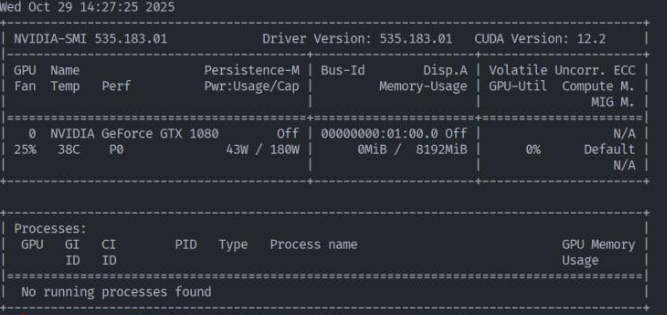